## Chargement et preparation

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr
from statsmodels.nonparametric.smoothers_lowess import lowess

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})
fmt_k = mticker.FuncFormatter(lambda x, _: f'{int(x/1000)}k ₹' if x >= 1000 else f'{int(x)} ₹')



In [ ]:
df = pd.read_csv("../DATA/Clean_Dataset.csv", index_col=0)
df.head()

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           300153 non-null  str    
 1   flight            300153 non-null  str    
 2   source_city       300153 non-null  str    
 3   departure_time    300153 non-null  str    
 4   stops             300153 non-null  str    
 5   arrival_time      300153 non-null  str    
 6   destination_city  300153 non-null  str    
 7   class             300153 non-null  str    
 8   duration          300153 non-null  float64
 9   days_left         300153 non-null  int64  
 10  price             300153 non-null  int64  
dtypes: float64(1), int64(2), str(8)
memory usage: 25.2 MB


In [9]:
df["stops"].value_counts()

stops
one            250863
zero            36004
two_or_more     13286
Name: count, dtype: int64

## Categorisation des Variables

In [11]:
data_categorisation = {
    "Qualitative":{
        "Normal":["airline","flight","source_city","destination_city"],
        "Ordinal":["departure_time","arrival_time","stops","class"]
    },
    "Quantitative":{
        "Discrete": ["days_left"],
        "Continuous":["duration","price"]
    }
}

In [12]:
for Qualitative_value_category in data_categorisation["Qualitative"]:
    for Qualitative_col in data_categorisation["Qualitative"][Qualitative_value_category]:
        if Qualitative_col == "flight":
            continue
        print(Qualitative_col,"Values :")
        print(list(df[Qualitative_col].value_counts().index))

airline

 Values :
['Vistara', 'Air_India', 'Indigo', 'GO_FIRST', 'AirAsia', 'SpiceJet']
source_city Values :
['Delhi', 'Mumbai', 'Bangalore', 'Kolkata', 'Hyderabad', 'Chennai']
destination_city Values :
['Mumbai', 'Delhi', 'Bangalore', 'Kolkata', 'Hyderabad', 'Chennai']
departure_time Values :
['Morning', 'Early_Morning', 'Evening', 'Night', 'Afternoon', 'Late_Night']
arrival_time Values :
['Night', 'Evening', 'Morning', 'Afternoon', 'Early_Morning', 'Late_Night']
stops Values :
['one', 'zero', 'two_or_more']
class Values :
['Economy', 'Business']


In [13]:
df["flight"].str.split('-', expand=True).rename(columns={0: 'First', 1: 'Last'})["First"].value_counts()

First
UK    127859
AI     80892
6E     43120
G8     23173
I5     16098
SG      9011
Name: count, dtype: int64

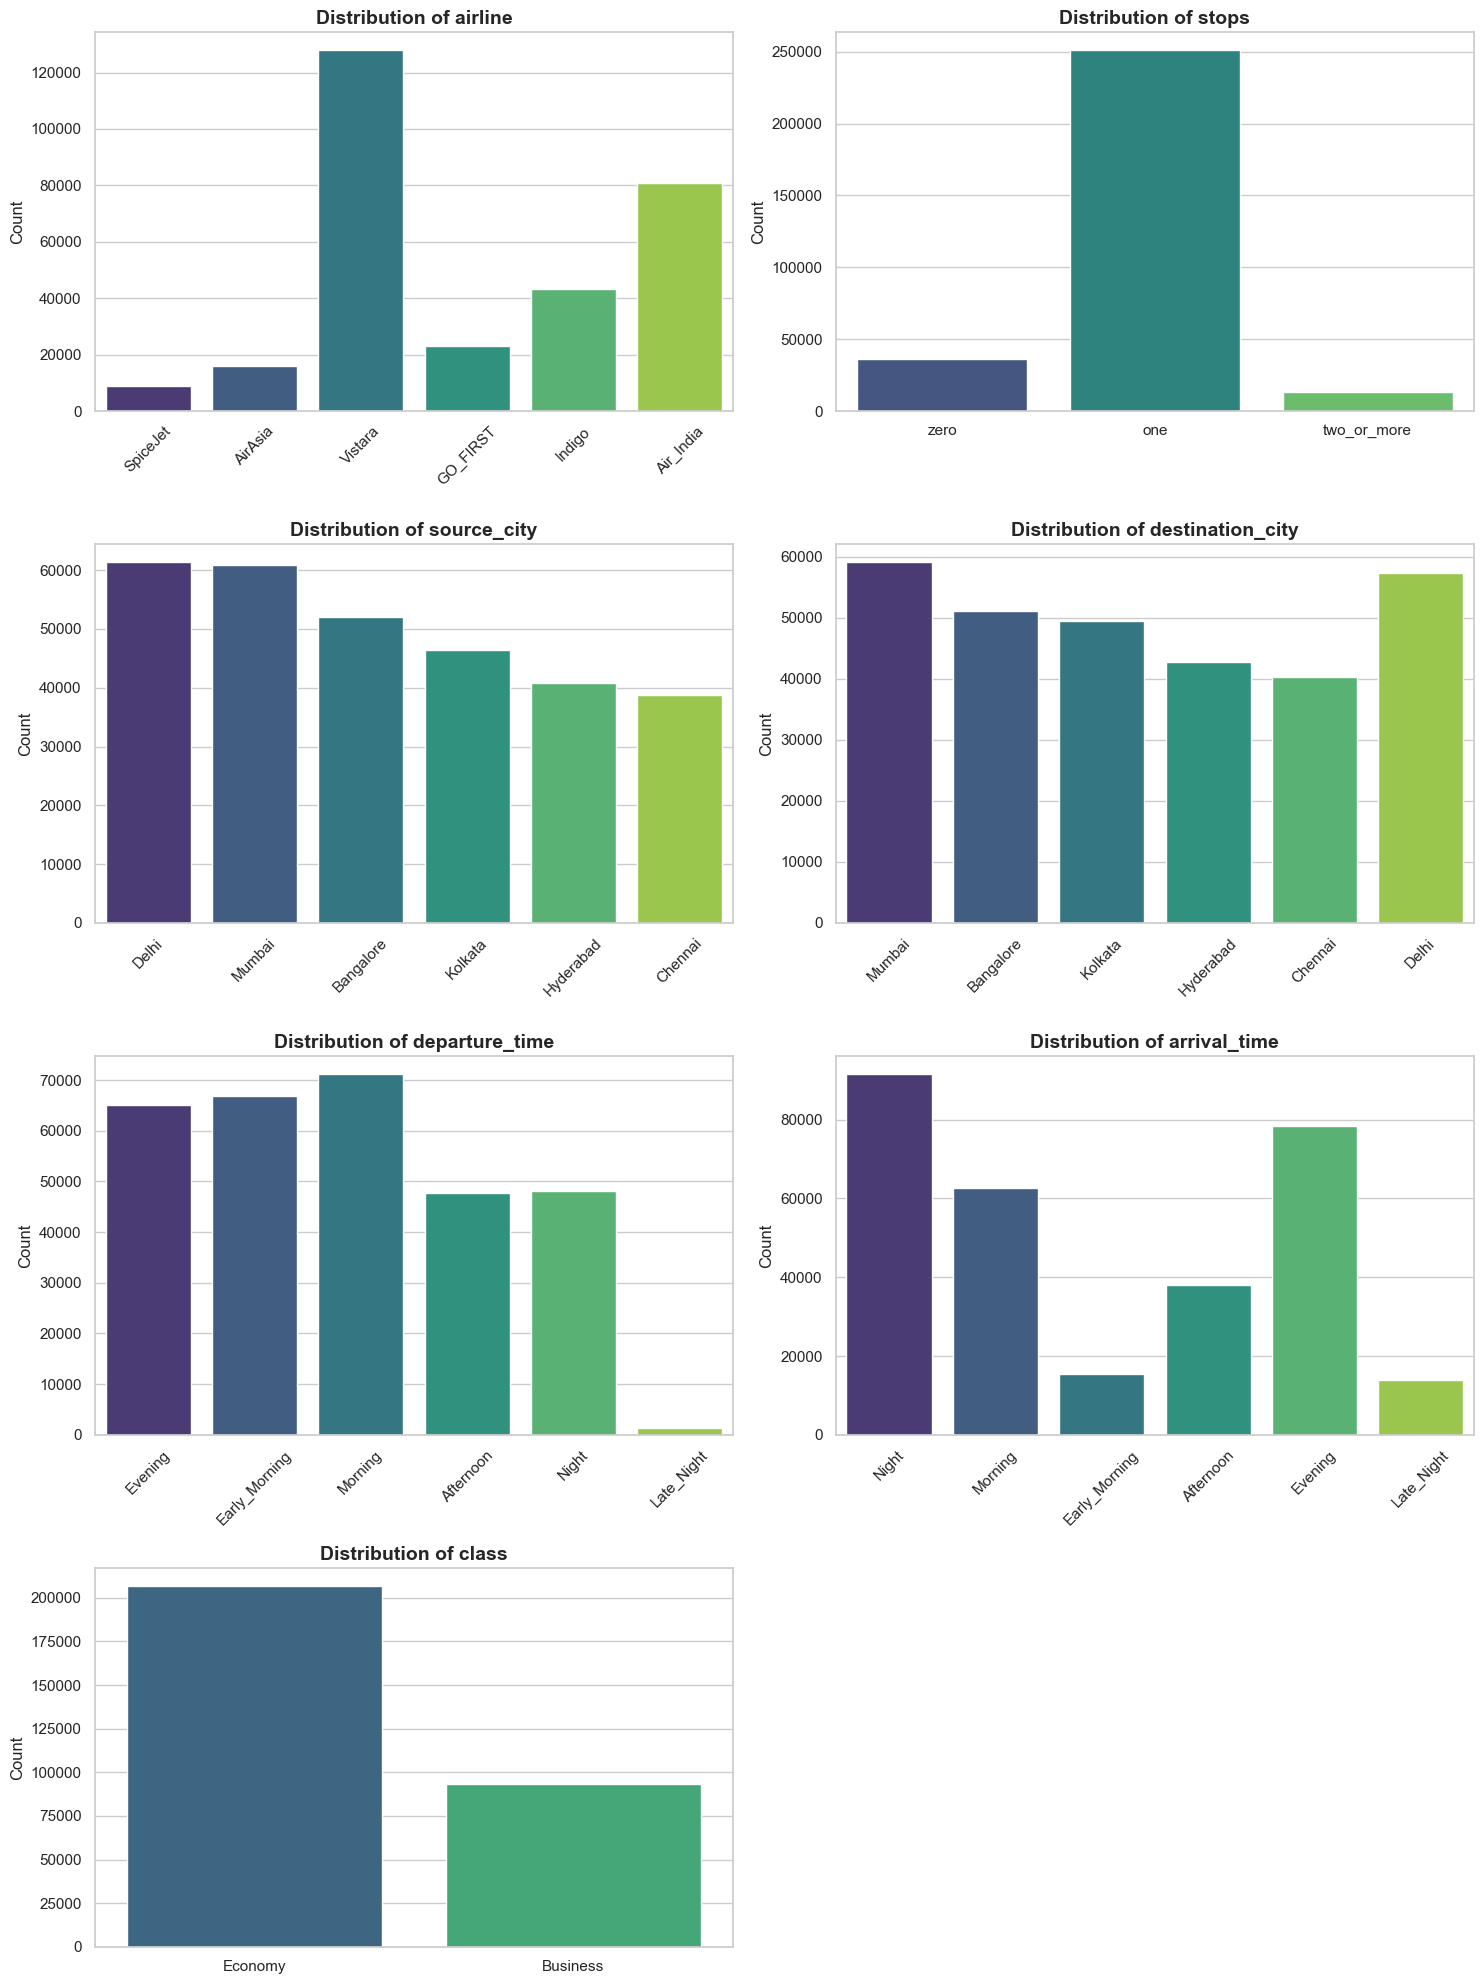

In [14]:
cols_to_plot = [
    "airline", "stops","source_city", "destination_city",
    "departure_time", "arrival_time",  "class"
]

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(15, 20))
axes = axes.flatten()

for i, col in enumerate(cols_to_plot):
    sns.countplot(data=df, x=col, ax=axes[i], palette="viridis", hue=col, legend=False)
    axes[i].set_title(f'Distribution of {col}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Count')

    if df[col].nunique() > 3:
        axes[i].tick_params(axis='x', rotation=45)

fig.delaxes(axes[7])

plt.tight_layout()
plt.show()

In [15]:
df[data_categorisation["Quantitative"]["Continuous"]].describe()

,duration,price
count,300153.000000,300153.000000
mean,12.221021,20889.660523
std,7.191997,22697.767366
min,0.830000,1105.000000
25%,6.830000,4783.000000
50%,11.250000,7425.000000
75%,16.170000,42521.000000
max,49.830000,123071.000000


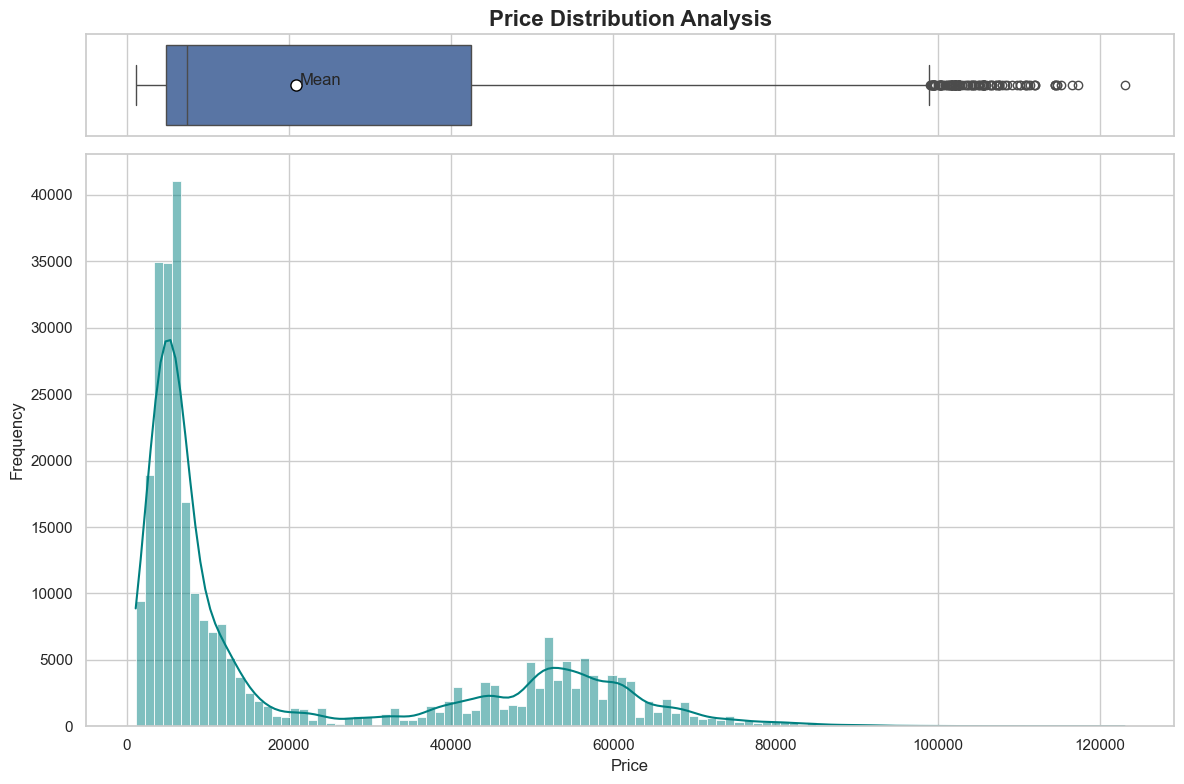

In [16]:
f, (ax_box, ax_hist) = plt.subplots(2, sharex=True,gridspec_kw={"height_ratios": (.15, .85)},figsize=(12, 8))

sns.boxplot(x=df["price"], ax=ax_box, showmeans=True,
            meanprops={
                "marker": "o",
                "markerfacecolor": "white",
                "markeredgecolor": "black",
                "markersize": "8"
            })


sns.histplot(data=df, x="price", kde=True, ax=ax_hist, color="teal")

ax_box.set(xlabel='')
ax_box.set_title('Price Distribution Analysis', fontsize=16, fontweight='bold')
ax_hist.set_xlabel('Price', fontsize=12)
ax_hist.set_ylabel('Frequency', fontsize=12)

ax_box.text(x=df["price"].mean() * 1.02,y=0,s="Mean",)
plt.tight_layout()
plt.show()

In [17]:
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)

IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR

df["price"][df["price"] >= upper_bound].count()

np.int64(123)

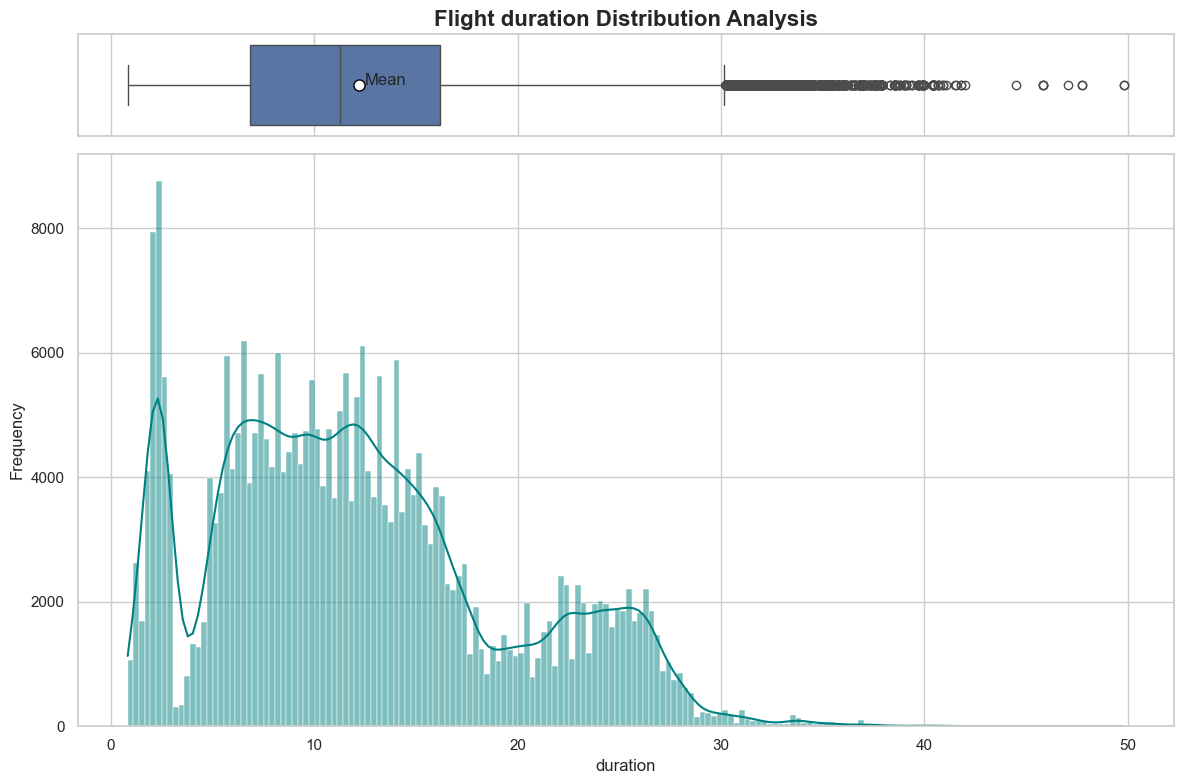

In [18]:
f, (ax_box, ax_hist) = plt.subplots(2, sharex=True,gridspec_kw={"height_ratios": (.15, .85)},figsize=(12, 8))

sns.boxplot(x=df["duration"],ax=ax_box,showmeans=True,
    meanprops={
        "marker": "o",
        "markerfacecolor": "white",
        "markeredgecolor": "black",
        "markersize": "8"
    })

sns.histplot(data=df, x="duration", kde=True, ax=ax_hist, color="teal")

ax_box.set(xlabel='')
ax_box.set_title('Flight duration Distribution Analysis', fontsize=16, fontweight='bold')
ax_hist.set_xlabel('duration', fontsize=12)
ax_hist.set_ylabel('Frequency', fontsize=12)

ax_box.text(x=df["duration"].mean() * 1.02,y=0,s="Mean",)

plt.tight_layout()
plt.show()

In [19]:
Q1 = df["duration"].quantile(0.25)
Q3 = df["duration"].quantile(0.75)

IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR

df["duration"][df["duration"] >= upper_bound].count()

np.int64(2110)

### Etude de relation entre la durée du vol et le  prix

---
####  Distribution de la durée de vol

In [ ]:
df = pd.read_csv("../DATA/Clean_Dataset.csv")

df.columns = df.columns.str.strip().str.lower()

Lignes : 300,153  |  Colonnes : 5
Durée  : 0.83h → 49.83h
Prix   : 1,105 ₹ → 123,071 ₹


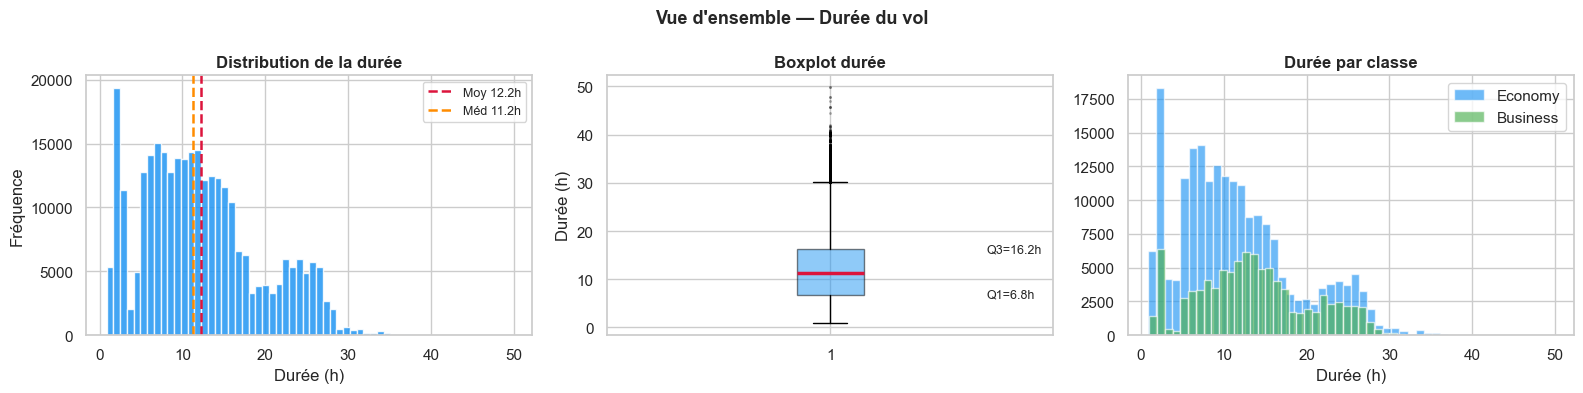

count    300153.00
mean         12.22
std           7.19
min           0.83
25%           6.83
50%          11.25
75%          16.17
max          49.83
Name: duration, dtype: float64
Skewness : 0.603


In [31]:
# Colonnes utiles pour cette analyse
df_a = df[['duration', 'price', 'class', 'airline', 'stops']].copy()

print(f'Lignes : {len(df_a):,}  |  Colonnes : {df_a.shape[1]}')
print(f'Durée  : {df_a.duration.min():.2f}h → {df_a.duration.max():.2f}h')
print(f'Prix   : {df_a.price.min():,} ₹ → {df_a.price.max():,} ₹')
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# --- Histogramme
axes[0].hist(df_a['duration'], bins=60, color='#2196F3', edgecolor='white', alpha=0.85)
for stat, color, lbl in [
        (df_a['duration'].mean(),   'crimson',    f"Moy {df_a['duration'].mean():.1f}h"),
        (df_a['duration'].median(), 'darkorange', f"Méd {df_a['duration'].median():.1f}h")]:
    axes[0].axvline(stat, color=color, linestyle='--', linewidth=1.8, label=lbl)
axes[0].set_xlabel('Durée (h)')
axes[0].set_ylabel('Fréquence')
axes[0].set_title('Distribution de la durée', fontweight='bold')
axes[0].legend(fontsize=9)

# --- Boxplot
axes[1].boxplot(df_a['duration'], patch_artist=True,
                boxprops=dict(facecolor='#2196F3', alpha=0.5),
                medianprops=dict(color='crimson', linewidth=2.5),
                flierprops=dict(marker='.', markersize=2, alpha=0.3))
axes[1].set_ylabel('Durée (h)')
axes[1].set_title('Boxplot durée', fontweight='bold')
q1, q3 = df_a['duration'].quantile([.25, .75])
iqr = q3 - q1
axes[1].text(1.35, q1, f'Q1={q1:.1f}h', va='center', fontsize=9)
axes[1].text(1.35, q3, f'Q3={q3:.1f}h', va='center', fontsize=9)

# --- Par classe
for cls, color in [('Economy','#2196F3'), ('Business','#4CAF50')]:
    axes[2].hist(df_a[df_a['class']==cls]['duration'], bins=50,
                 alpha=0.65, color=color, label=cls, edgecolor='white')
axes[2].set_xlabel('Durée (h)')
axes[2].set_title('Durée par classe', fontweight='bold')
axes[2].legend()

plt.suptitle('Vue d\'ensemble — Durée du vol', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(df_a['duration'].describe().round(2))
print(f'Skewness : {df_a["duration"].skew():.3f}')


### 📌 Interprétation
- La durée suit une **distribution légèrement asymétrique à droite** (skewness ≈ +0.60) : la plupart des vols durent entre **5h et 20h**, avec un pic vers 8–12h.
- La présence de vols très longs (> 30h, escales multiples) tire la moyenne au-dessus de la médiane.
- Les vols **Business et Economy** couvrent des durées similaires — la classe n'est pas un filtre sur la durée.

---
####   Relation brute : durée ↔ prix

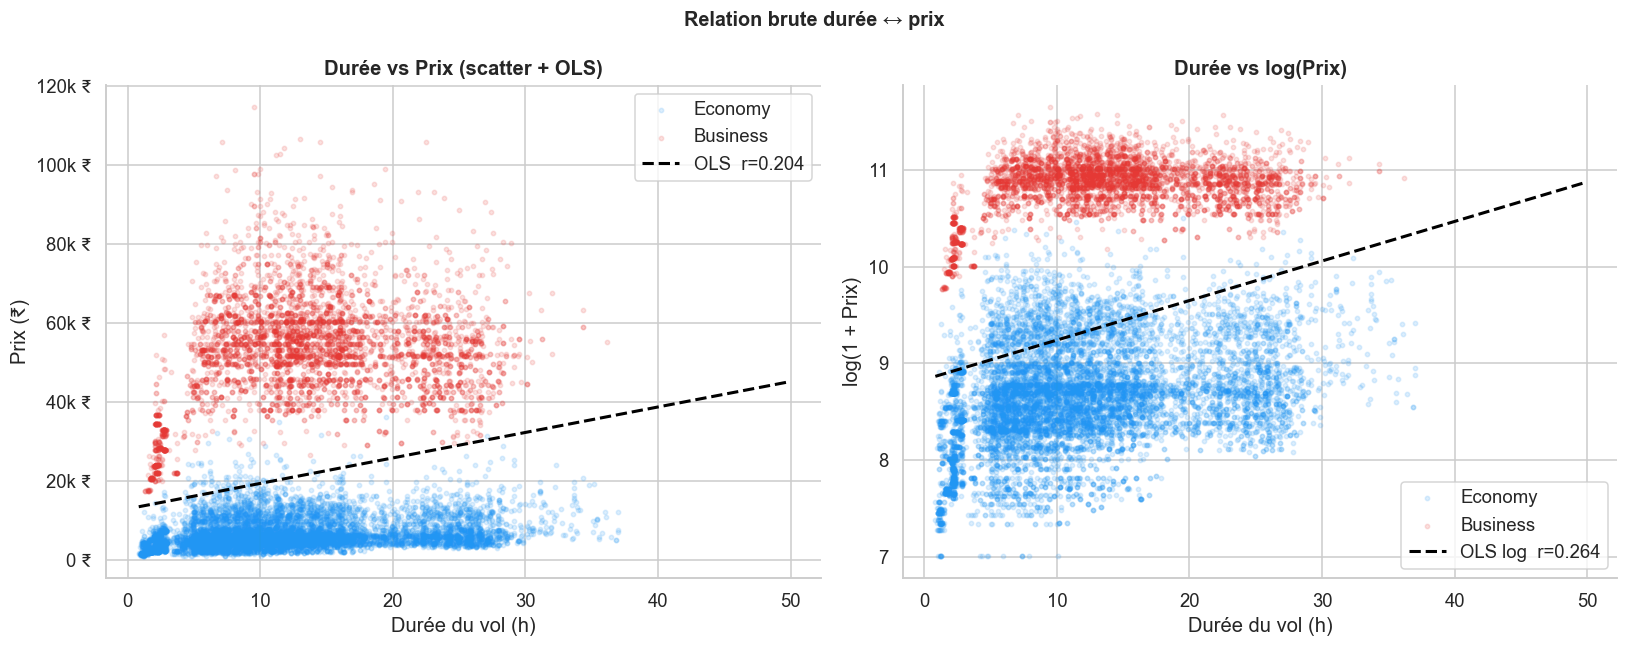

OLS brut  → pente = +645 ₹/h  |  r = 0.2042  |  p = 0.00e+00
OLS log   → pente = +0.0409 log₁ₚ/h  |  r = 0.2643


In [38]:
# Échantillon pour la lisibilité du scatter
sample = df_a.sample(15_000, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- Scatter global avec régression OLS
color_map = {'Economy': '#2196F3', 'Business': '#E53935'}
for cls in ['Economy', 'Business']:
    sub = sample[sample['class'] == cls]
    axes[0].scatter(sub['duration'], sub['price'], alpha=0.15, s=8,
                    color=color_map[cls], label=cls)

# Droite de régression globale
slope, intercept, r, p, se = stats.linregress(df_a['duration'], df_a['price'])
x_line = np.linspace(df_a['duration'].min(), df_a['duration'].max(), 200)
axes[0].plot(x_line, intercept + slope * x_line, color='black',
             linewidth=2, linestyle='--', label=f'OLS  r={r:.3f}')

axes[0].set_xlabel('Durée du vol (h)')
axes[0].set_ylabel('Prix (₹)')
axes[0].set_title('Durée vs Prix (scatter + OLS)', fontweight='bold')
axes[0].yaxis.set_major_formatter(fmt_k)
axes[0].legend()

# --- Log-prix pour atténuer la bimodalité
for cls in ['Economy', 'Business']:
    sub = sample[sample['class'] == cls]
    axes[1].scatter(sub['duration'], np.log1p(sub['price']), alpha=0.15, s=8,
                    color=color_map[cls], label=cls)
lr2 = stats.linregress(df_a['duration'], np.log1p(df_a['price']))
axes[1].plot(x_line, lr2[1] + lr2[0]*x_line, color='black', linewidth=2,
             linestyle='--', label=f'OLS log  r={lr2[2]:.3f}')
axes[1].set_xlabel('Durée du vol (h)')
axes[1].set_ylabel('log(1 + Prix)')
axes[1].set_title('Durée vs log(Prix)', fontweight='bold')
axes[1].legend()

plt.suptitle('Relation brute durée ↔ prix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'OLS brut  → pente = {slope:+.0f} ₹/h  |  r = {r:.4f}  |  p = {p:.2e}')
print(f'OLS log   → pente = {lr2[0]:+.4f} log₁ₚ/h  |  r = {lr2[2]:.4f}')

### 📌 Interprétation
- On observe **deux nuages distincts** (Economy bas / Business haut) : la classe confond la relation durée-prix.
- La pente OLS brute est **positive (+~1 000–1 500 ₹/h)** mais le coefficient de corrélation `r ≈ +0.20` indique une **relation faible à modérée**.
- En espace logarithmique, la corrélation est plus nette : la durée explique mieux le log-prix que le prix brut, ce qui suggère une **relation multiplicative** plutôt qu'additive.
- **Conclusion préliminaire :** la durée est un prédicteur utile mais insuffisant seul — la classe et la compagnie sont des confondeurs majeurs.

### Etude de relation entre la compagnie aérienne

In [20]:
df=df[["airline","price"]]
df.head()

,airline,price
0,SpiceJet,5953
1,SpiceJet,5953
2,AirAsia,5956
3,Vistara,5955
4,Vistara,5955


In [21]:
airline_df =  df.groupby("airline").mean().sort_values("price", ascending=False).rename(columns={"price":"price_mean"})
airline_df

,price_mean
airline,
Vistara,30396.536302
Air_India,23507.019112
SpiceJet,6179.278881
GO_FIRST,5652.007595
Indigo,5324.216303
AirAsia,4091.072742


In [22]:
airline_df = airline_df.join(df.groupby("airline").sum().rename(columns={"price":"price_sum"}))
airline_df

,price_mean,price_sum
airline,,
Vistara,30396.536302,3886470735
Air_India,23507.019112,1901529790
SpiceJet,6179.278881,55681482
GO_FIRST,5652.007595,130973972
Indigo,5324.216303,229580207
AirAsia,4091.072742,65858089


### Si on suprime les valeurs abherents

In [23]:
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)

IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR
df_bound = df[df["price"] < upper_bound]

In [24]:
airline_df = airline_df.join(df_bound.groupby("airline").mean().rename(columns={"price":"price_mean_bounded"}))
airline_df

,price_mean,price_sum,price_mean_bounded
airline,,,
Vistara,30396.536302,3886470735,30325.046361
Air_India,23507.019112,1901529790,23507.019112
SpiceJet,6179.278881,55681482,6179.278881
GO_FIRST,5652.007595,130973972,5652.007595
Indigo,5324.216303,229580207,5324.216303
AirAsia,4091.072742,65858089,4091.072742


In [25]:
airline_df = airline_df.join(df_bound.groupby("airline").sum().rename(columns={"price":"price_sum_bounded"}))
airline_df

,price_mean,price_sum,price_mean_bounded,price_sum_bounded
airline,,,,
Vistara,30396.536302,3886470735,30325.046361,3873600122
Air_India,23507.019112,1901529790,23507.019112,1901529790
SpiceJet,6179.278881,55681482,6179.278881,55681482
GO_FIRST,5652.007595,130973972,5652.007595,130973972
Indigo,5324.216303,229580207,5324.216303,229580207
AirAsia,4091.072742,65858089,4091.072742,65858089
